# Quick overview of space missions data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [ ]:
# Load the dataset
df = pd.read_csv('all_space_mission_launches.csv')
# Extract country from location (last part after comma)
df['Country'] = df['Location'].str.split(',').str[-1].str.strip()
df.head(10)

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,7.5,Success
5,5,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Tue Jan 30, 2024 17:07 UTC",Falcon 9 Block 5 | CRS NG-20,Active,67.0,Success
6,6,SpaceX,"SLC-4E, Vandenberg SFB, California, USA","Mon Jan 29, 2024 05:57 UTC",Falcon 9 Block 5 | Starlink Group 7-12,Active,67.0,Success
7,7,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Mon Jan 29, 2024 01:10 UTC",Falcon 9 Block 5 | Starlink Group 6-38,Active,67.0,Success
8,8,ISA,"Imam Khomeini Spaceport, Semnan Space Center, ...","Sun Jan 28, 2024 00:04 UTC","Simorgh | Mahda, Keyhan-2 & Hatef-1",Active,NaN,Success
9,9,Virgin Galactic,"VMS Eve, Spaceport America, New Mexico, USA","Fri Jan 26, 2024 17:42 UTC",SpaceShipTwo | Galactic-06,Active,NaN,Success


## All space missions

In [ ]:
# Dataset shape and basic info
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print("\nData types:")
print(df.dtypes)

Dataset shape: 6711 rows, 7 columns

Columns: ['Organisation', 'Location', 'Datetime', 'Details', 'Rocket_Status', 'Price', 'Mission_Status']

Data types:
Organisation       object
Location           object
Datetime           object
Details            object
Rocket_Status      object
Price             float64
Mission_Status     object
dtype: object


### Null values

In [7]:
# Check for null values
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Percentage (%)': null_percentages})
print("Null values per column:")
print(null_df)

Null values per column:
                Null Count  Percentage (%)
Unnamed: 0               0            0.00
Organisation             0            0.00
Location                 0            0.00
Datetime                 0            0.00
Details                  0            0.00
Rocket_Status            0            0.00
Price                 4074           60.71
Mission_Status           0            0.00


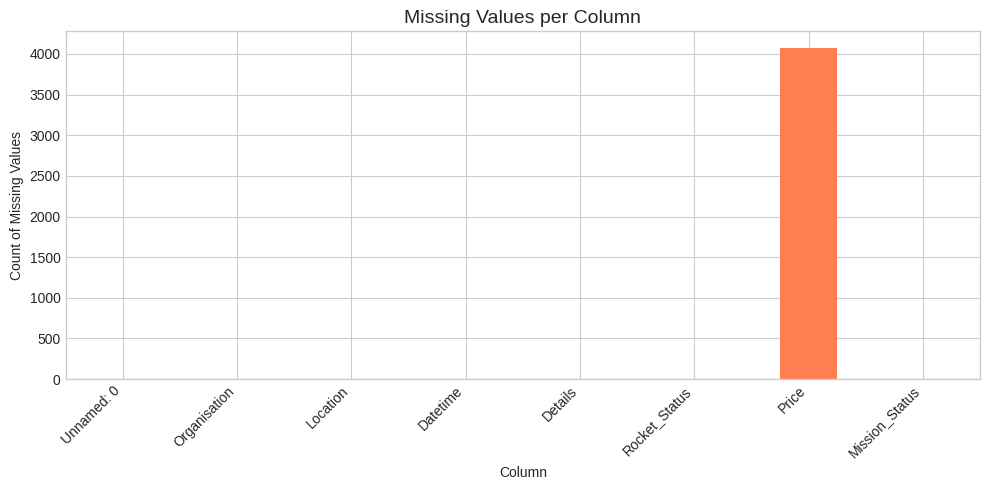

In [ ]:
# Visualize null values
fig, ax = plt.subplots(figsize=(10, 5))
null_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Missing Values per Column', fontsize=14)
ax.set_xlabel('Column')
ax.set_ylabel('Count of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Mission Status Analysis

Mission Status Distribution:
Mission_Status
Success              6134
Failure               455
Partial Failure       114
Prelaunch Failure       8
Name: count, dtype: int64


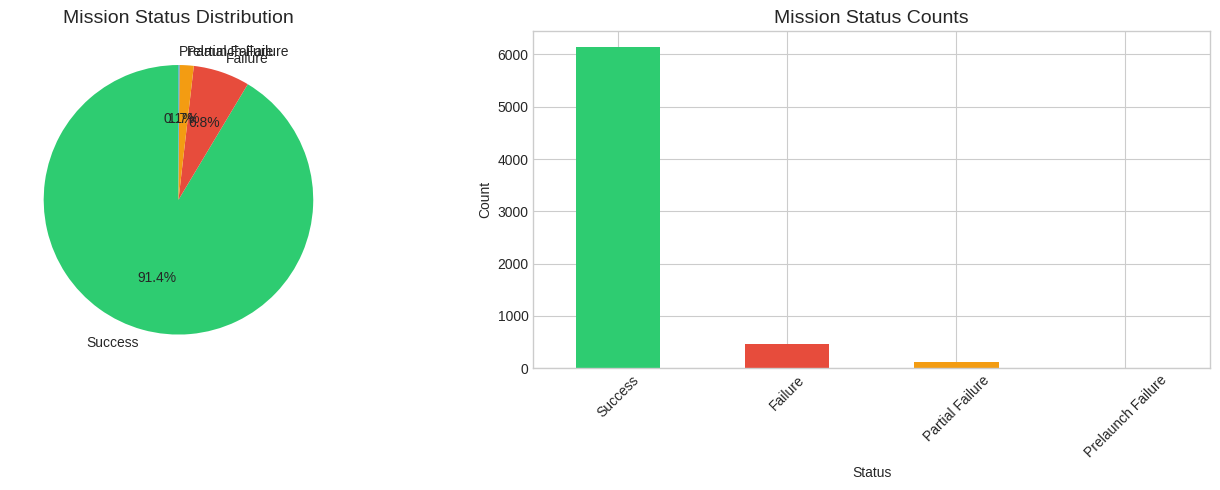

In [8]:
# Mission status distribution
mission_status_counts = df['Mission_Status'].value_counts()
print("Mission Status Distribution:")
print(mission_status_counts)

# Pie chart for mission status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
axes[0].pie(mission_status_counts.values, labels=mission_status_counts.index, 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Mission Status Distribution', fontsize=14)

# Bar chart
mission_status_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Mission Status Counts', fontsize=14)
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Top Organizations

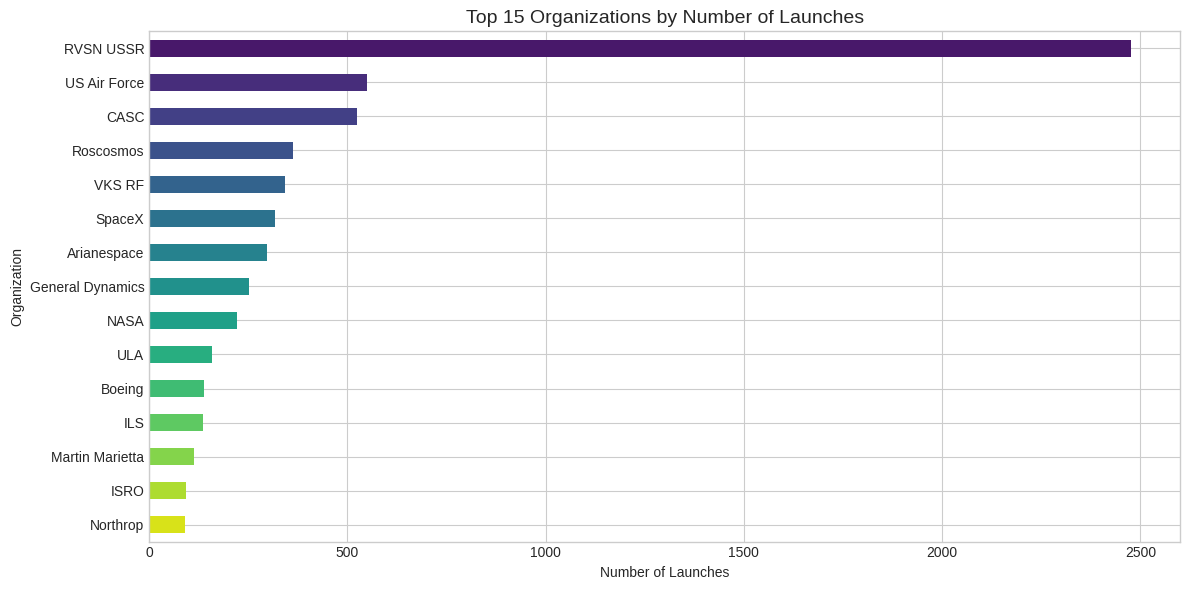


Total unique organizations: 66


In [9]:
# Top 15 organizations by number of launches
top_orgs = df['Organisation'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_orgs.plot(kind='barh', ax=ax, color=sns.color_palette("viridis", len(top_orgs)))
ax.set_title('Top 15 Organizations by Number of Launches', fontsize=14)
ax.set_xlabel('Number of Launches')
ax.set_ylabel('Organization')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal unique organizations: {df['Organisation'].nunique()}")

### Rocket Status

Rocket Status Distribution:
Rocket_Status
Retired    5240
Active     1471
Name: count, dtype: int64


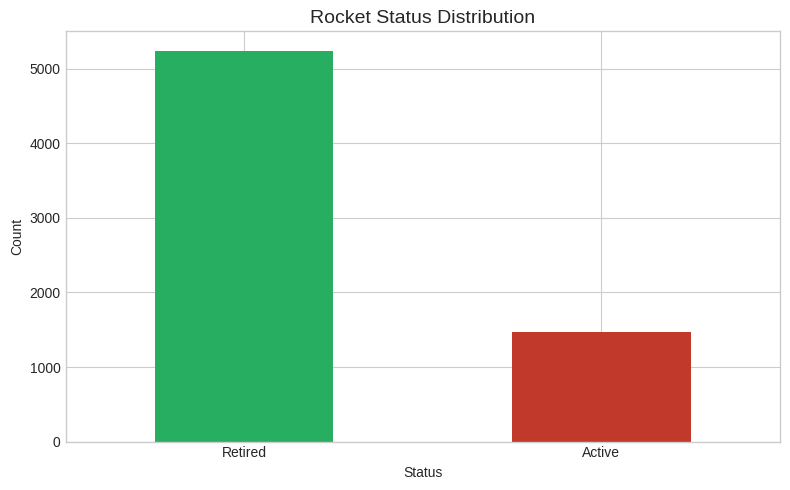

In [10]:
# Rocket status distribution
rocket_status = df['Rocket_Status'].value_counts()
print("Rocket Status Distribution:")
print(rocket_status)

fig, ax = plt.subplots(figsize=(8, 5))
rocket_status.plot(kind='bar', ax=ax, color=['#27ae60', '#c0392b'])
ax.set_title('Rocket Status Distribution', fontsize=14)
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Launch Locations

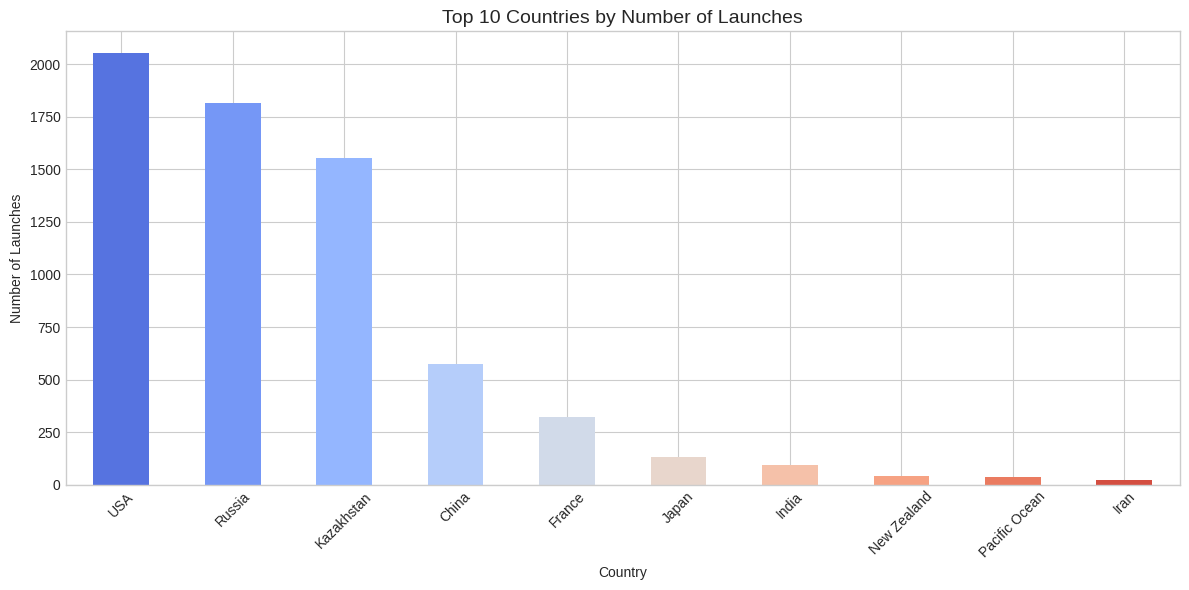

In [ ]:
# Top 10 countries by launches
top_countries = df['Country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind='bar', ax=ax, color=sns.color_palette("coolwarm", len(top_countries)))
ax.set_title('Top 10 Countries by Number of Launches', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Number of Launches')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Mission Costs Analysis

Missions with price data: 2637 out of 6711 (39.3%)

Price Statistics (in millions USD):
count    2637.000000
mean       69.162321
std       101.440856
min         2.500000
25%        20.000000
50%        30.000000
75%        67.000000
max       876.000000
Name: Price, dtype: float64


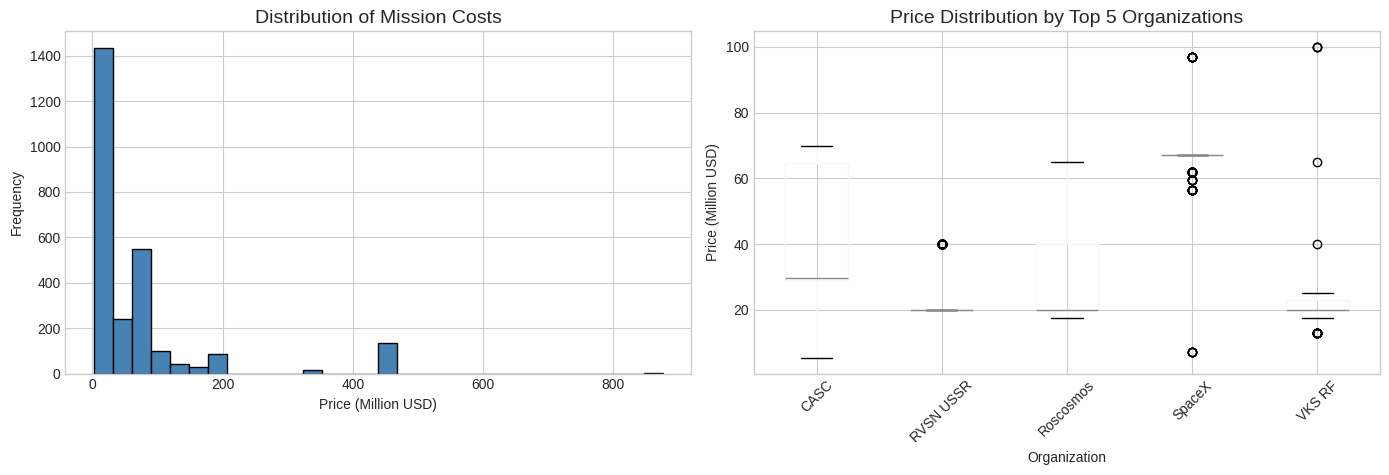

In [12]:
# Price analysis (note: Price has many null values)
df_with_price = df[df['Price'].notna()].copy()
print(f"Missions with price data: {len(df_with_price)} out of {len(df)} ({len(df_with_price)/len(df)*100:.1f}%)")
print(f"\nPrice Statistics (in millions USD):")
print(df_with_price['Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of prices
axes[0].hist(df_with_price['Price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Mission Costs', fontsize=14)
axes[0].set_xlabel('Price (Million USD)')
axes[0].set_ylabel('Frequency')

# Box plot of prices by top organizations
top_5_orgs = df_with_price['Organisation'].value_counts().head(5).index
df_top_orgs = df_with_price[df_with_price['Organisation'].isin(top_5_orgs)]
df_top_orgs.boxplot(column='Price', by='Organisation', ax=axes[1])
axes[1].set_title('Price Distribution by Top 5 Organizations', fontsize=14)
axes[1].set_xlabel('Organization')
axes[1].set_ylabel('Price (Million USD)')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Launches Over Time

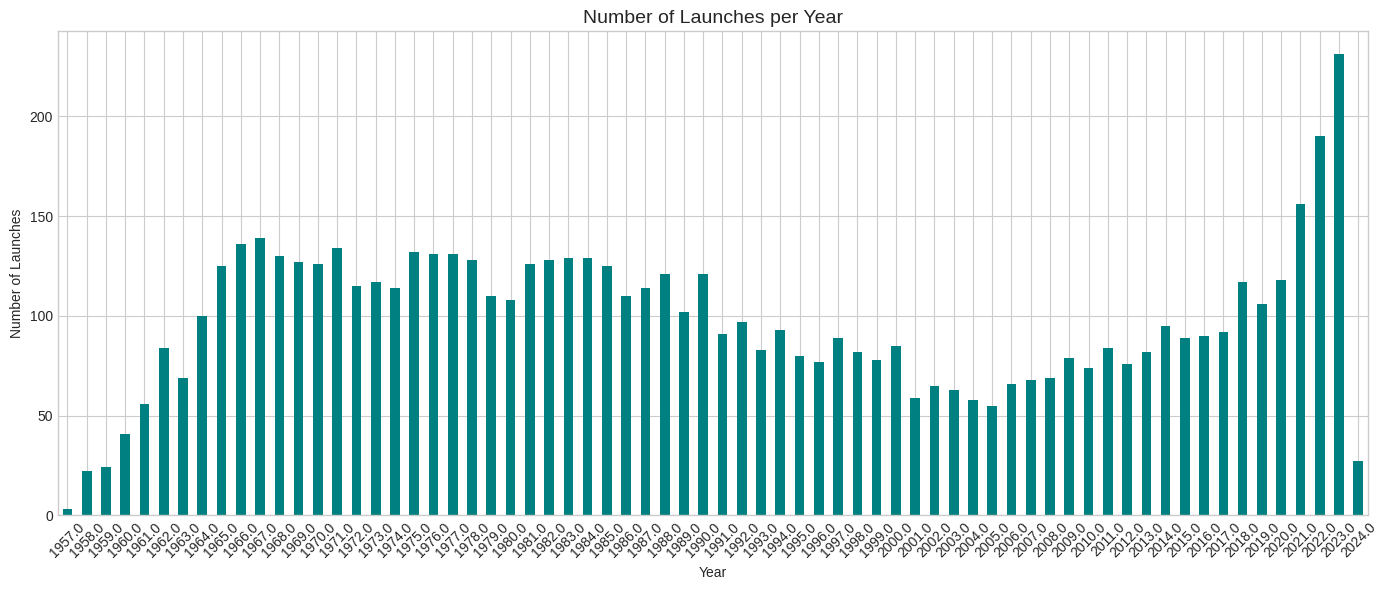

In [13]:
# Parse datetime and extract year/month
df['Datetime_parsed'] = pd.to_datetime(df['Datetime'], format='%a %b %d, %Y %H:%M UTC', errors='coerce')
df['Year'] = df['Datetime_parsed'].dt.year
df['Month'] = df['Datetime_parsed'].dt.month
df['YearMonth'] = df['Datetime_parsed'].dt.to_period('M')

# Launches per year
launches_per_year = df.groupby('Year').size()

fig, ax = plt.subplots(figsize=(14, 6))
launches_per_year.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Number of Launches per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Launches')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

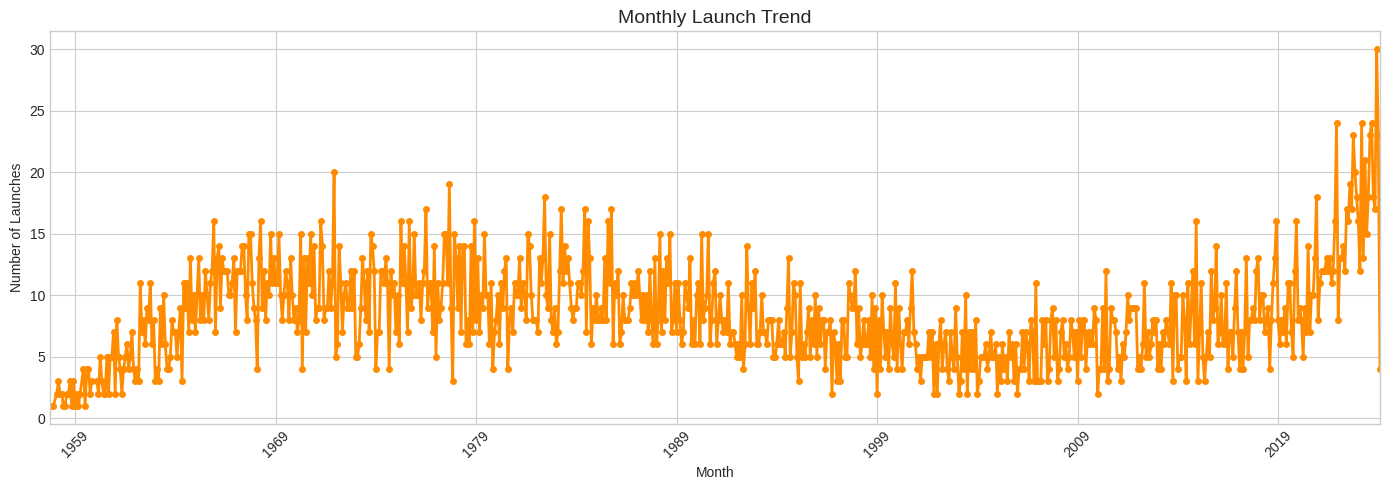

In [14]:
# Monthly launches trend (last 2 years available)
recent_data = df[df['Datetime_parsed'].notna()].copy()
recent_launches = recent_data.groupby('YearMonth').size()

fig, ax = plt.subplots(figsize=(14, 5))
recent_launches.plot(ax=ax, marker='o', linewidth=2, markersize=4, color='darkorange')
ax.set_title('Monthly Launch Trend', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Launches')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Success Rate by Organization

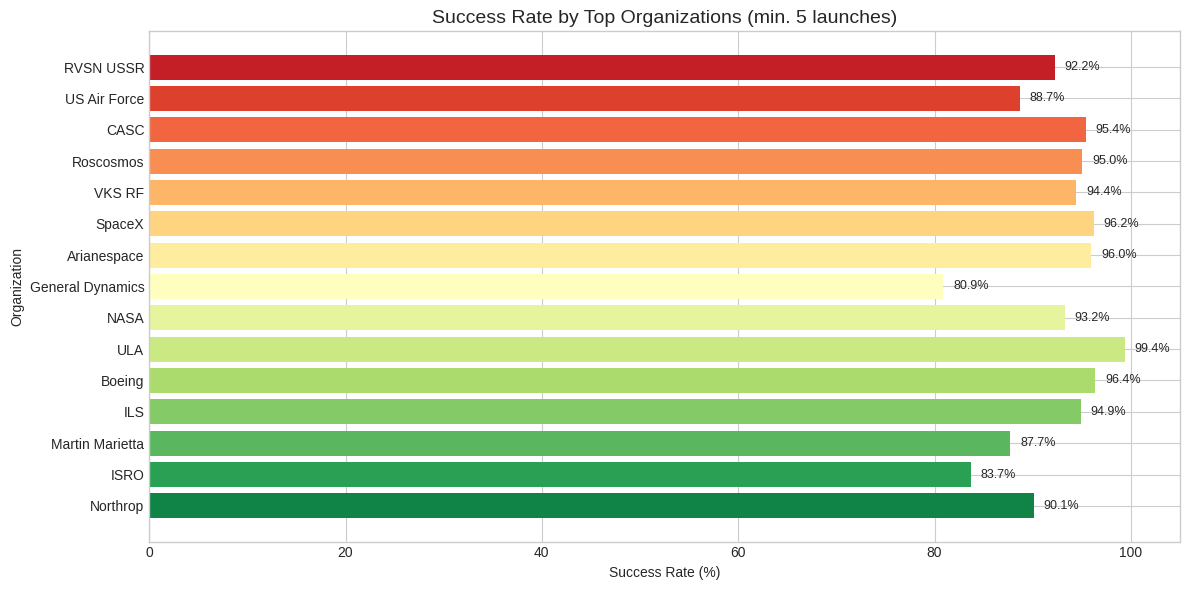

In [15]:
# Calculate success rate for organizations with at least 5 launches
org_stats = df.groupby('Organisation').agg({
    'Mission_Status': ['count', lambda x: (x == 'Success').sum()]
}).reset_index()
org_stats.columns = ['Organisation', 'Total_Launches', 'Successful_Launches']
org_stats['Success_Rate'] = (org_stats['Successful_Launches'] / org_stats['Total_Launches'] * 100).round(2)

# Filter for organizations with at least 5 launches
org_stats_filtered = org_stats[org_stats['Total_Launches'] >= 5].sort_values('Total_Launches', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(org_stats_filtered['Organisation'], org_stats_filtered['Success_Rate'], 
               color=sns.color_palette("RdYlGn", len(org_stats_filtered)))
ax.set_xlim(0, 105)
ax.set_title('Success Rate by Top Organizations (min. 5 launches)', fontsize=14)
ax.set_xlabel('Success Rate (%)')
ax.set_ylabel('Organization')
ax.invert_yaxis()

# Add percentage labels
for bar, rate in zip(bars, org_stats_filtered['Success_Rate']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Summary Statistics

In [16]:
# Summary statistics
print("=" * 50)
print("SPACE MISSIONS DATASET SUMMARY")
print("=" * 50)
print(f"\nTotal missions: {len(df)}")
print(f"Date range: {df['Datetime_parsed'].min().strftime('%Y-%m-%d')} to {df['Datetime_parsed'].max().strftime('%Y-%m-%d')}")
print(f"\nUnique organizations: {df['Organisation'].nunique()}")
print(f"Unique countries: {df['Country'].nunique()}")
print(f"\nMission outcomes:")
for status, count in df['Mission_Status'].value_counts().items():
    print(f"  - {status}: {count} ({count/len(df)*100:.1f}%)")
print(f"\nOverall success rate: {(df['Mission_Status'] == 'Success').sum() / len(df) * 100:.1f}%")
print(f"\nAverage mission cost: ${df['Price'].mean():.2f}M (for missions with price data)")
print(f"Most active organization: {df['Organisation'].value_counts().index[0]} ({df['Organisation'].value_counts().values[0]} launches)")

SPACE MISSIONS DATASET SUMMARY

Total missions: 6711
Date range: 1957-10-04 to 2024-02-09

Unique organizations: 66
Unique countries: 22

Mission outcomes:
  - Success: 6134 (91.4%)
  - Failure: 455 (6.8%)
  - Partial Failure: 114 (1.7%)
  - Prelaunch Failure: 8 (0.1%)

Overall success rate: 91.4%

Average mission cost: $69.16M (for missions with price data)
Most active organization: RVSN USSR (2476 launches)


---
# The Space Race (1957-1975)

Analysis of space missions during the Cold War competition between the USA and the USSR.

In [ ]:
# Filter data for Space Race era (1957-1975)
df_space_race = df[(df['Year'] >= 1957) & (df['Year'] <= 1975)].copy()

# Drop the Price column
df_space_race = df_space_race.drop(columns=['Price'])

print(f"Total missions during the Space Race (1957-1975): {len(df_space_race)}")
print(f"\nCountries in this period:")
print(df_space_race['Country'].value_counts())

In [ ]:
# Check organizations during this period
print("Organizations during the Space Race era:")
print(df_space_race['Organisation'].value_counts())

In [ ]:
# Define function to classify missions as USA, USSR, or Other
def classify_superpower(row):
    """
    Classify launches as USA, USSR, or Other based on country and organization.
    
    USSR launches came from:
    - Russia (RSFSR during Soviet era)
    - Kazakhstan (Baikonur Cosmodrome was the main Soviet launch site)
    
    Organizations associated with USSR:
    - RVSN USSR (Soviet Strategic Rocket Forces)
    - VKS RF (became Russian Aerospace Forces, but during USSR was Soviet)
    - Roscosmos predecessors
    """
    country = row['Country']
    org = row['Organisation']
    
    # USA identification
    usa_keywords = ['USA', 'United States']
    if any(kw in str(country) for kw in usa_keywords):
        return 'USA'
    
    # USSR identification - countries that were part of Soviet space program
    ussr_countries = ['Russia', 'Kazakhstan']
    ussr_orgs = ['RVSN USSR', 'VKS RF', 'Roscosmos', 'Soviet']
    
    if any(c in str(country) for c in ussr_countries):
        return 'USSR'
    if any(o in str(org) for o in ussr_orgs):
        return 'USSR'
    
    return 'Other'

# Apply classification
df_space_race['Superpower'] = df_space_race.apply(classify_superpower, axis=1)

print("Classification of Space Race missions:")
print(df_space_race['Superpower'].value_counts())
print(f"\n'Other' countries include: {df_space_race[df_space_race['Superpower'] == 'Other']['Country'].unique()}")

In [ ]:
# Preview the Space Race dataframe
print(f"Space Race Dataset: {len(df_space_race)} missions")
print(f"Columns: {list(df_space_race.columns)}")
df_space_race.head(10)

## USA vs USSR: Total Launches Comparison

In [ ]:
# Filter to only USA and USSR
df_superpowers = df_space_race[df_space_race['Superpower'].isin(['USA', 'USSR'])].copy()

# Total launches comparison
superpower_counts = df_superpowers['Superpower'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_sp = {'USA': '#3498db', 'USSR': '#e74c3c'}
bars = axes[0].bar(superpower_counts.index, superpower_counts.values, 
                   color=[colors_sp[x] for x in superpower_counts.index])
axes[0].set_title('Total Launches: USA vs USSR (1957-1975)', fontsize=14)
axes[0].set_ylabel('Number of Launches')
axes[0].set_xlabel('Superpower')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(superpower_counts.values, labels=superpower_counts.index, 
            autopct='%1.1f%%', colors=[colors_sp[x] for x in superpower_counts.index],
            startangle=90, explode=[0.02, 0.02])
axes[1].set_title('Share of Launches: USA vs USSR', fontsize=14)

plt.tight_layout()
plt.show()

## Launches Over Time: The Race Progression

In [ ]:
# Launches per year by superpower
launches_by_year = df_superpowers.groupby(['Year', 'Superpower']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))

# Grouped bar chart
x = range(len(launches_by_year.index))
width = 0.35

bars_usa = ax.bar([i - width/2 for i in x], launches_by_year['USA'], width, 
                  label='USA', color='#3498db')
bars_ussr = ax.bar([i + width/2 for i in x], launches_by_year['USSR'], width, 
                   label='USSR', color='#e74c3c')

ax.set_xlabel('Year')
ax.set_ylabel('Number of Launches')
ax.set_title('Annual Launches: USA vs USSR (1957-1975)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(launches_by_year.index.astype(int), rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cumulative launches over time
cumulative = launches_by_year.cumsum()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(cumulative.index, cumulative['USA'], marker='o', linewidth=2, 
        markersize=6, color='#3498db', label='USA')
ax.plot(cumulative.index, cumulative['USSR'], marker='s', linewidth=2, 
        markersize=6, color='#e74c3c', label='USSR')

ax.fill_between(cumulative.index, cumulative['USA'], alpha=0.3, color='#3498db')
ax.fill_between(cumulative.index, cumulative['USSR'], alpha=0.3, color='#e74c3c')

ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Number of Launches')
ax.set_title('Cumulative Launches: USA vs USSR (1957-1975)', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Add annotations for key milestones
ax.axvline(x=1957, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=1969, color='gold', linestyle='--', alpha=0.7, label='Moon Landing (1969)')

plt.tight_layout()
plt.show()

## Mission Success Rates

In [ ]:
# Success rates by superpower
success_stats = df_superpowers.groupby('Superpower').agg({
    'Mission_Status': ['count', lambda x: (x == 'Success').sum()]
}).reset_index()
success_stats.columns = ['Superpower', 'Total', 'Successful']
success_stats['Failed'] = success_stats['Total'] - success_stats['Successful']
success_stats['Success_Rate'] = (success_stats['Successful'] / success_stats['Total'] * 100).round(2)

print("Mission Success Statistics:")
print(success_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Success rate comparison
colors_sp = {'USA': '#3498db', 'USSR': '#e74c3c'}
bars = axes[0].bar(success_stats['Superpower'], success_stats['Success_Rate'],
                   color=[colors_sp[x] for x in success_stats['Superpower']])
axes[0].set_ylim(0, 100)
axes[0].set_title('Mission Success Rate: USA vs USSR', fontsize=14)
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_xlabel('Superpower')

for bar, rate in zip(bars, success_stats['Success_Rate']):
    axes[0].annotate(f'{rate:.1f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Stacked bar for success/failure breakdown
x = range(len(success_stats))
axes[1].bar(success_stats['Superpower'], success_stats['Successful'], 
            label='Success', color='#27ae60')
axes[1].bar(success_stats['Superpower'], success_stats['Failed'], 
            bottom=success_stats['Successful'], label='Failure', color='#c0392b')
axes[1].set_title('Mission Outcomes: Success vs Failure', fontsize=14)
axes[1].set_ylabel('Number of Missions')
axes[1].set_xlabel('Superpower')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Success rate evolution over time
success_by_year = df_superpowers.groupby(['Year', 'Superpower']).apply(
    lambda x: (x['Mission_Status'] == 'Success').sum() / len(x) * 100
).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(success_by_year.index, success_by_year['USA'], marker='o', linewidth=2, 
        markersize=6, color='#3498db', label='USA')
ax.plot(success_by_year.index, success_by_year['USSR'], marker='s', linewidth=2, 
        markersize=6, color='#e74c3c', label='USSR')

ax.set_xlabel('Year')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Mission Success Rate Evolution (1957-1975)', fontsize=14)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Organizations in the Space Race

In [ ]:
# Organizations by superpower
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, superpower in enumerate(['USA', 'USSR']):
    orgs = df_superpowers[df_superpowers['Superpower'] == superpower]['Organisation'].value_counts()
    color = '#3498db' if superpower == 'USA' else '#e74c3c'
    orgs.plot(kind='barh', ax=axes[idx], color=color)
    axes[idx].set_title(f'{superpower} Organizations', fontsize=14)
    axes[idx].set_xlabel('Number of Launches')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

## Launch Sites

In [ ]:
# Top launch sites by superpower
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, superpower in enumerate(['USA', 'USSR']):
    sites = df_superpowers[df_superpowers['Superpower'] == superpower]['Location'].value_counts().head(8)
    # Shorten location names for better display
    short_names = [loc.split(',')[0][:30] for loc in sites.index]
    color = '#3498db' if superpower == 'USA' else '#e74c3c'
    
    axes[idx].barh(short_names, sites.values, color=color)
    axes[idx].set_title(f'{superpower} Launch Sites', fontsize=14)
    axes[idx].set_xlabel('Number of Launches')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

## Rocket Status

In [ ]:
# Rocket status by superpower
rocket_status_sp = df_superpowers.groupby(['Superpower', 'Rocket_Status']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(rocket_status_sp.index))
width = 0.35

if 'Active' in rocket_status_sp.columns:
    ax.bar([i - width/2 for i in x], rocket_status_sp.get('Active', 0), width, 
           label='Active', color='#27ae60')
if 'Retired' in rocket_status_sp.columns:
    ax.bar([i + width/2 for i in x], rocket_status_sp.get('Retired', 0), width, 
           label='Retired', color='#95a5a6')

ax.set_xlabel('Superpower')
ax.set_ylabel('Number of Rockets')
ax.set_title('Rocket Status by Superpower', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(rocket_status_sp.index)
ax.legend()

plt.tight_layout()
plt.show()

## Space Race Summary

In [ ]:
# Comprehensive summary
print("=" * 60)
print("THE SPACE RACE (1957-1975) - SUMMARY")
print("=" * 60)

for superpower in ['USA', 'USSR']:
    sp_data = df_superpowers[df_superpowers['Superpower'] == superpower]
    total = len(sp_data)
    successful = (sp_data['Mission_Status'] == 'Success').sum()
    success_rate = successful / total * 100 if total > 0 else 0
    first_launch = sp_data['Datetime_parsed'].min()
    orgs = sp_data['Organisation'].nunique()
    
    print(f"\n{superpower}:")
    print(f"  Total launches: {total}")
    print(f"  Successful missions: {successful}")
    print(f"  Success rate: {success_rate:.1f}%")
    print(f"  First launch in period: {first_launch.strftime('%Y-%m-%d') if pd.notna(first_launch) else 'N/A'}")
    print(f"  Unique organizations: {orgs}")
    print(f"  Most active org: {sp_data['Organisation'].value_counts().index[0]}")

print("\n" + "=" * 60)
print("COMPARISON:")
print("=" * 60)
usa_total = len(df_superpowers[df_superpowers['Superpower'] == 'USA'])
ussr_total = len(df_superpowers[df_superpowers['Superpower'] == 'USSR'])
leader = 'USSR' if ussr_total > usa_total else 'USA'
diff = abs(ussr_total - usa_total)
print(f"\nTotal Space Race missions (USA + USSR): {len(df_superpowers)}")
print(f"Launch leader: {leader} (by {diff} launches)")
print(f"USSR/USA launch ratio: {ussr_total/usa_total:.2f}x" if usa_total > 0 else "")